In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import h5py
import torch
import torch.nn.functional as F
from torchinfo import summary
from sklearn.model_selection import train_test_split

import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.gridspec as gs

In [9]:
df_pd = pd.read_hdf("/global/cfs/cdirs/m3246/twamorka/omnifold_atlas/pelican_zjets/pd.h5", key="table")
df_testmc = pd.read_hdf("/global/cfs/cdirs/m3246/twamorka/omnifold_atlas/pelican_zjets/testmc.h5", key="table")
df_trainmc = pd.read_hdf("/global/cfs/cdirs/m3246/twamorka/omnifold_atlas/pelican_zjets/trainmc.h5", key="table")

In [20]:
df_pd

,E_0,PX_0,PY_0,PZ_0,pt_0,eta_0,phi_0,E_1,PX_1,PY_1,...,PZ_393,PZ_394,PZ_395,PZ_396,PZ_397,PZ_398,PZ_399,PZ_400,PZ_401,is_signal
entry,,,,,,,,,,,,,,,,,,,,,
0,358.376404,-61.123329,123.885254,330.681152,138.143463,1.607032,2.029139,324.761719,7.829883,61.982212,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,233.749039,-34.148113,-229.126282,31.203671,231.656952,0.134294,-1.718744,57.249554,1.092959,-33.771400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,355.898834,139.568329,-19.315348,-326.820404,140.898544,-1.578044,-0.137520,213.848953,138.419739,20.205450,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,282.667328,179.753326,-105.405533,190.995361,208.378464,0.821139,-0.530352,76.030121,73.143044,-17.943634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,189.350555,143.362381,-30.127684,119.971603,146.493851,0.747400,-0.207136,88.542076,72.268326,43.005123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247247,208.209045,-41.966919,-193.935822,63.076794,198.424606,0.312764,-1.783906,76.595375,-11.270577,-70.878349,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
247248,463.030212,93.913521,179.805130,-416.229889,202.853729,-1.466596,1.089463,58.582478,38.213032,11.709779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
247249,490.863953,-297.739319,72.881020,383.388947,306.529510,1.048056,2.901532,61.693485,-26.457933,-21.114206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
e_l1_pd = df_pd["E_0"]
e_l1_testmc = df_testmc["E_0"]
e_l1_trainmc = df_trainmc["E_0"]

px_l1_pd = df_pd["PX_0"]
px_l1_testmc = df_testmc["PX_0"]
px_l1_trainmc = df_trainmc["PX_0"]

py_l1_pd = df_pd["PY_0"]
py_l1_testmc = df_testmc["PY_0"]
py_l1_trainmc = df_trainmc["PY_0"]

pz_l1_pd = df_pd["PZ_0"]
pz_l1_testmc = df_testmc["PZ_0"]
pz_l1_trainmc = df_trainmc["PZ_0"]



In [30]:
e_l2_pd = df_pd["E_1"]
e_l2_testmc = df_testmc["E_1"]
e_l2_trainmc = df_trainmc["E_1"]

px_l2_pd = df_pd["PX_1"]
px_l2_testmc = df_testmc["PX_1"]
px_l2_trainmc = df_trainmc["PX_1"]

py_l2_pd = df_pd["PY_1"]
py_l2_testmc = df_testmc["PY_1"]
py_l2_trainmc = df_trainmc["PY_1"]

pz_l2_pd = df_pd["PZ_1"]
pz_l2_testmc = df_testmc["PZ_1"]
pz_l2_trainmc = df_trainmc["PZ_1"]

In [31]:
def mkplot(var_pd, var_testmc, var_trainmc, var, bin_start, bin_end, nbins):
    bins = np.linspace(bin_start, bin_end, nbins)
    plt.hist(var_pd, bins=bins, alpha=0.5, label='PD', density=True, histtype='step' )
    plt.hist(var_testmc, bins=bins, alpha=0.5, label='Test MC', density=True, histtype='step' )    
    plt.hist(var_trainmc, bins=bins, alpha=0.5, label='Train MC', density=True, histtype='step' )    
    plt.legend(loc='center right')
    plt.yscale('log')
    plt.xlabel(var)
    plt.ylabel('A.U.')
    plt.savefig(var+".pdf")
    plt.close()
    # plt.show()

In [32]:
mkplot(e_l1_pd, e_l1_testmc, e_l1_trainmc, "E_l1", 0, 5000, 150)

In [33]:
mkplot(px_l1_pd, px_l1_testmc, px_l1_trainmc, "Px_l1", -3000, 3000, 150)
mkplot(py_l1_pd, py_l1_testmc, py_l1_trainmc, "Py_l1", -3000, 3000, 150)
mkplot(pz_l1_pd, pz_l1_testmc, pz_l1_trainmc, "Pz_l1", -3000, 3000, 150)

In [35]:
mkplot(e_l2_pd, e_l2_testmc, e_l2_trainmc, "E_l2", 0, 3000, 150)
mkplot(px_l2_pd, px_l2_testmc, px_l2_trainmc, "Px_l2", -2000, 2000, 150)
mkplot(py_l2_pd, py_l2_testmc, py_l2_trainmc, "Py_l2", -2000, 2000, 150)
mkplot(pz_l2_pd, pz_l2_testmc, pz_l2_trainmc, "Pz_l2", -2000, 2000, 150)

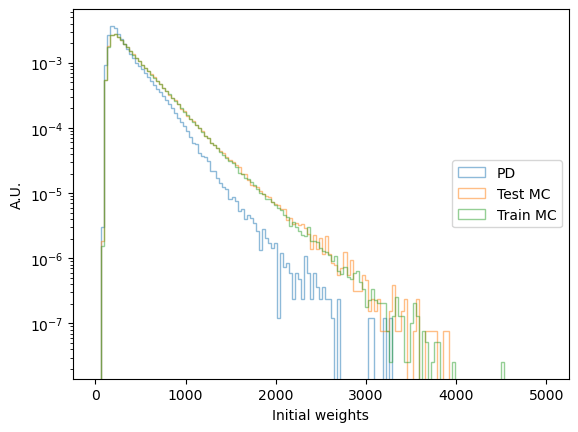

In [16]:
bins = np.linspace(0, 5000, 150)
plt.hist(e_l1_pd, bins=bins, alpha=0.5, label='PD', density=True, histtype='step' )
plt.hist(e_l1_testmc, bins=bins, alpha=0.5, label='Test MC', density=True, histtype='step' )
plt.hist(e_l1_trainmc, bins=bins, alpha=0.5, label='Train MC', density=True, histtype='step' )
# add_stats_box(plt.gca(), mc_weights)
plt.legend(loc='center right')
plt.yscale('log')
plt.xlabel('Initial weights')
plt.ylabel('A.U.')
plt.show()
# plt.savefig('initialweights_MC.pdf')